# Vesuvius Challenge - 使用 nnUNet 进行表面检测

**目的：** 使用 nnUNetv2 的 3D 语义分割基线，用于在 Vesuvius Challenge 的 CT 体数据中检测纸草（papyrus）表面。

**比赛链接：** https://www.kaggle.com/competitions/vesuvius-challenge-surface-detection

### 问题概述
- 输入：古代纸草卷轴的 3D CT 体数据（.tif 文件）
- 输出：二值分割掩码，标记纸草表面像素
- 难点：部分标注（某些区域没有 ground truth）

### 方案思路
利用 nnUNet 内置的 **ignore label（忽略标签）** 机制：
- 标签 0 = 背景
- 标签 1 = 纸草表面  
- 标签 2 = 未标注/忽略（训练时不参与损失计算）

nnUNet 会自动处理部分标注（partial labels）：仅在已知标签（0 或 1）的像素上计算梯度，同时忽略标签 2 的区域。

### 本基线的关键特性
1. **原生 TIFF 支持** - 自定义 SimpleTiffIO 读取器，无需转 NIfTI
2. **基于符号链接的数据准备** - 无需拷贝大文件，准备速度快
3. **预处理缓存** - 可上传为 Kaggle Dataset 以跳过预处理
4. **多 GPU 支持** - 自动检测并使用 DDP 训练
5. **可配置训练轮数** - 使用 nnUNet 内置训练器变体（1-8000 epochs）
6. **可视化工具** - 训练曲线与预测可视化

### 目录结构
```
/kaggle/input/vesuvius-challenge-surface-detection/
├── train_images/*.tif      # 训练 CT 体数据
├── train_labels/*.tif      # 训练标签（0=背景, 1=表面, 2=忽略）
└── test_images/*.tif       # 测试 CT 体数据（无标签）

/kaggle/temp/nnUNet_data/    # 工作目录（会话结束会清理）
├── nnUNet_raw/              # 指向比赛数据的符号链接
└── nnUNet_preprocessed/     # 预处理后的数据（可缓存为 Kaggle dataset）

/kaggle/working/             # 持久化输出
├── nnUNet_results/          # 训练好的模型与 checkpoint
├── predictions_tiff/        # 推理输出
└── submission.zip           # 最终提交文件
```

### 用法
1. **快速开始：** 直接运行 `full_pipeline()`（使用默认配置）
2. **快速实验：** 使用 `epochs=50` 或 `config="2d"`
3. **正式训练：** 建议 `epochs=250-500`，使用 `3d_fullres` 或 `3d_lowres`
4. **断点续训：** 使用 `continue_training=True`

### 性能说明
- 预处理：约 1-2 小时（可通过缓存跳过）
- 训练：在 T4 上约 5-10 分钟/epoch，更强 GPU 可约 2-3 分钟/epoch
- fold="all" 验证：训练结束后会在全部训练数据上做验证（可能较慢）
- 推理：每个体数据约 1-2 分钟

### 对话检查点
这份代码是一个自包含 baseline。关键决策如下：
- 使用 nnUNetPlannerResEncM（ResNet 编码器，中等规模）- 速度/质量较均衡
- 使用 3d_fullres 配置 - 单阶段分割质量最好
- 使用 fold="all" - 使用全部训练数据训练，不做交叉验证（更适合快速出提交）
- 默认启用多 GPU（自动检测）
- model_path 会从路径结构中自动解析 epochs/plans/config/fold

---

### 常用命令速查
```bash
# 预处理
nnUNetv2_plan_and_preprocess -d 100 -np 4 -pl nnUNetPlannerResEncM

# 训练（会自动使用 ignore label 机制）
nnUNetv2_train 100 3d_fullres 0 -p nnUNetResEncUNetMPlans

# 更少 epochs 的训练（更快）
nnUNetv2_train 100 3d_fullres 0 -p nnUNetResEncUNetMPlans -tr nnUNetTrainer_250epochs

# 并行训练所有 fold（不同 GPU）
CUDA_VISIBLE_DEVICES=0 nnUNetv2_train 100 3d_fullres 0 ... &
CUDA_VISIBLE_DEVICES=1 nnUNetv2_train 100 3d_fullres 1 ... &

# 多 GPU DDP 训练（单个 fold，多张 GPU）
nnUNetv2_train 100 3d_fullres 0 ... -num_gpus 2

# 推理
nnUNetv2_predict -d 100 -c 3d_fullres -f 0 -i INPUT -o OUTPUT -p nnUNetResEncUNetMPlans
```

### 配置参考

#### Configurations（配置）
| 配置 | 适用场景 | 速度 | 质量 |
|--------|----------|-------|---------|
| `2d` | 快速实验，逐切片 | 最快 | 较低 |
| `3d_lowres` | 大体数据，折中方案 | 快 | 好 |
| `3d_fullres` | 质量优先，小体数据 | 慢 | 最好 |
| `3d_cascade_fullres` | 超大体数据（两阶段） | 最慢 | 最好 |

#### Planners（规划器）
| Planner | Plans 名称 | 说明 |
|---------|------------|-------|
| `nnUNetPlanner` | `nnUNetPlans` | 默认 U-Net |
| `nnUNetPlannerResEncM` | `nnUNetResEncUNetMPlans` | ResNet 编码器，中等规模（推荐） |
| `nnUNetPlannerResEncL` | `nnUNetResEncUNetLPlans` | ResNet 编码器，大规模 |

#### 可选 Epoch 数（内置训练器变体）
```
1, 5, 10, 20, 50, 100, 250, 500, 750, 1000, 2000, 4000, 8000
```
- `epochs=None` 或 `1000` = 默认完整训练
- `epochs=50-100` = 快速实验
- `epochs=250-500` = 通常较好的折中

### 超参数调参指南

**nnUNet 会自动配置大多数参数。** 通常只需要在必要时调整少量选项：

#### nnUNet 自动配置的内容（一般不建议手动改）
- Patch size（根据显存与数据自动决定）
- Batch size（根据显存自动决定）
- 网络结构深度
- 归一化方案
- 数据增强
- 学习率调度（poly LR：`lr = initial_lr * (1 - epoch/max_epochs)^0.9`）

#### 你可以调整的内容
| 参数 | 默认值 | 如何修改 | 何时修改 |
|-----------|---------|---------------|----------------|
| **Epochs** | 1000 | `epochs=250` | 如果模型提前收敛（看 progress.png） |
| **Planner** | nnUNetPlanner | `planner="nnUNetPlannerResEncM"` | 可能带来更高精度 |
| **Folds** | 5-fold CV | `fold="all"` | 时间/算力有限 |
| **Config** | 3d_fullres | `config="2d"` 或 `"3d_lowres"` | 需要更快实验 |
| **GPUs** | auto | `num_gpus=2` | 多 GPU 训练 |

#### 建议的调参顺序
1. **先用默认** - nnUNet 开箱即用已经很强
2. **优先尝试 ResEnc planner** - 往往能带来 1-2% 提升
3. **如果提前收敛**，把 epochs 调到 250-500（看 progress.png）
4. **先用 2d 做快速迭代**，再切到 3d_fullres
5. 一般不要手动调 batch/patch/LR - nnUNet 会处理

### 参考资料
- [nnUNet GitHub](https://github.com/MIC-DKFZ/nnUNet)
- [nnUNet Ignore Label 文档](https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/ignore_label.md)
- [Vesuvius Challenge](https://scrollprize.org/)
- Isensee et al. (2021) - nnU-Net: Nature Methods
- Gotkowski et al. - Partial annotations paper（ignore label 支持相关）

## 1. 配置与导入

**本节概要：**
本节定义了整条 pipeline 的可配置参数。你可以修改这些参数以适配自己的训练/推理需求。

**关键配置决策：**
- `FOLD="all"`：使用全部训练数据训练，不做交叉验证（更适合快速提交）
- `CONFIGURATION="3d_lowres"`：对大体数据而言速度与质量折中较好
- `NUM_GPUS=auto`：DDP 训练时自动使用可用 GPU
- `EPOCHS=None`：默认 1000 epochs（如果提前收敛可降到 250-500）

**预处理数据缓存：**
若想跳过 1-2 小时的预处理：
1. 先完整跑一次预处理
2. 把 `nnUNet_preprocessed` 文件夹上传为 Kaggle Dataset
3. 将 `PREPARED_PREPROCESSED_PATH` 指向该 dataset 路径

**路径结构：**
- INPUT_DIR：比赛数据（只读）
- WORKING_DIR：临时文件（/kaggle/temp，会话结束清理）
- OUTPUT_DIR：持久化输出（/kaggle/working）

In [ ]:
import os
import json
import shutil
import subprocess
from functools import partial
from multiprocessing import Pool
from pathlib import Path
from typing import Optional, Tuple, List, Literal, Union

# =============================================================================
# 类型定义
# =============================================================================

# nnUNet 内置训练器支持的 epoch 数
# 这些是 nnUNet 预定义的 trainer 类，不能随便写任意数值
# 参考：nnunetv2/training/nnUNetTrainer/variants/training_length/nnUNetTrainer_Xepochs.py
Epochs = Literal[1, 5, 10, 20, 50, 100, 250, 500, 750, 1000, 2000, 4000, 8000]

# =============================================================================
# 配置项 - 根据你的环境修改
# =============================================================================

# 比赛数据路径（Kaggle dataset）
INPUT_DIR = Path("/kaggle/input/vesuvius-challenge-surface-detection")

# 已准备好的 nnUNet 预处理数据集
# 你可以把预处理后的数据上传为 Kaggle dataset，从而跳过 1-2 小时的预处理
# 如果想强制重新预处理，把它设置成一个不存在的路径
PREPARED_PREPROCESSED_PATH = Path("/kaggle/input/vesuvius-surface-nnunet-preprocessed")

# 工作目录
WORKING_DIR = Path("/kaggle/temp")  # 大量中间文件（会话结束清理）
OUTPUT_DIR = Path("/kaggle/working")  # 最终输出（持久化）

# nnUNet 目录结构（遵循 nnUNet 约定）
NNUNET_BASE = WORKING_DIR / "nnUNet_data"
NNUNET_RAW = NNUNET_BASE / "nnUNet_raw"  # 小：通过符号链接指向比赛数据
NNUNET_PREPROCESSED = NNUNET_BASE / "nnUNet_preprocessed"  # 大：可使用已准备的预处理数据
NNUNET_RESULTS = OUTPUT_DIR / "nnUNet_results"  # 训练产物（持久化）

# 数据集配置
DATASET_ID = 100  # nnUNet 数据集 ID（任意，但要保持一致）
DATASET_NAME = f"Dataset{DATASET_ID:03d}_VesuviusSurface"

# =============================================================================
# 训练配置
# =============================================================================

# Fold：0-4 表示 5 折交叉验证；"all" 表示用全部训练数据训练
# - 提交通常用 "all"（更快、数据更多）
# - 想评估/集成可用 0-4
FOLD: Union[int, str] = "all"

# Configuration：决定网络结构与分辨率
# - "2d"：最快，逐切片处理（适合快速实验）
# - "3d_lowres"：较快，适合大体数据（注意：会为 cascade 产生 predicted_next_stage）
# - "3d_fullres"：质量最好，单阶段（推荐）
# - "3d_cascade_fullres"：两阶段，适合超大体数据（最慢，依赖 3d_lowres 结果）
CONFIGURATION = "3d_fullres"

# Planner：决定网络结构变体
# - "nnUNetPlanner"：标准 U-Net 编码器
# - "nnUNetPlannerResEncM"：ResNet 编码器，中等规模（推荐，经常能提升 1-2%）
# - "nnUNetPlannerResEncL"：ResNet 编码器，大规模（参数更多、更慢）
PLANNER = "nnUNetPlannerResEncM"
PLANS_NAME = "nnUNetResEncUNetMPlans"  # 必须与 planner 匹配（见开头参考表）

# 预处理/数据准备的 CPU worker 数
NUM_WORKERS = os.cpu_count() or 4

# Epochs：训练轮数
# - None 或 1000：默认完整训练
# - 50-100：快速实验
# - 250-500：较好的折中（建议看 progress.png 判断是否已收敛）
# 必须是以下之一：1, 5, 10, 20, 50, 100, 250, 500, 750, 1000, 2000, 4000, 8000
EPOCHS: Optional[Epochs] = None

# 命令超时时间（秒），None 表示不超时
# Kaggle 9 小时限制下可设置，比如 28800（8 小时）留出缓冲
COMMAND_TIMEOUT: Optional[int] = None


def _get_gpu_count() -> int:
    """获取可用的 CUDA GPU 数量。"""
    try:
        import torch
        return torch.cuda.device_count() if torch.cuda.is_available() else 1
    except ImportError:
        return 0


# DDP 训练用 GPU 数
NUM_GPUS: int = _get_gpu_count()

# =============================================================================
# 路径辅助函数
# =============================================================================

def _get_trainer_name_simple(epochs: Optional[int]) -> str:
    """根据 epochs 返回 trainer 类名（用于拼接输出路径）。"""
    if epochs is None or epochs == 1000:
        return "nnUNetTrainer"
    elif epochs == 1:
        return "nnUNetTrainer_1epoch"  # 特殊：单数形式
    else:
        return f"nnUNetTrainer_{epochs}epochs"


def get_training_output_dir(
    epochs: Optional[Epochs] = None,
    plans: str = PLANS_NAME,
    config: str = CONFIGURATION,
    fold: Union[int, str] = FOLD
) -> Path:
    """
    根据配置获取训练输出目录。
    
    nnUNet 会创建如下结构：
    NNUNET_RESULTS/Dataset100_VesuviusSurface/nnUNetTrainer__nnUNetResEncUNetMPlans__3d_lowres/fold_all/
    
    可用它定位 checkpoint、日志和 progress.png
    """
    _epochs = epochs if epochs is not None else EPOCHS
    trainer = _get_trainer_name_simple(_epochs)
    return NNUNET_RESULTS / DATASET_NAME / f"{trainer}__{plans}__{config}" / f"fold_{fold}"


def get_progress_image_path(
    epochs: Optional[Epochs] = None,
    plans: str = PLANS_NAME,
    config: str = CONFIGURATION,
    fold: Union[int, str] = FOLD
) -> Path:
    """获取训练进度图（loss 曲线等）的路径。"""
    return get_training_output_dir(epochs, plans, config, fold) / "progress.png"

## 2. 环境设置

**本节概要：**
设置 nnUNet 所需的环境变量与目录结构。

**nnUNet 环境变量：**
- `nnUNet_raw`：nnUNet 查找原始数据集的位置
- `nnUNet_preprocessed`：预处理数据存放位置
- `nnUNet_results`：训练结果（模型）保存位置
- `nnUNet_compile`：是否启用 torch.compile（可能导致兼容性问题）

**预处理缓存数据处理：**
`_link_prepared_preprocessed()` 用于处理已缓存的预处理数据：
- 复制 nnUNet 可能需要修改的元数据文件（JSON、PKL 等）
- 对体积很大的数据文件（NPZ、B2ND）创建符号链接以节省空间
- 同时支持两种结构：直接指向 Dataset 文件夹，或指向其父目录

In [ ]:
def setup_environment():
    """设置 nnUNet 环境变量与目录结构。"""
    for d in [NNUNET_RAW, NNUNET_PREPROCESSED, NNUNET_RESULTS, OUTPUT_DIR]:
        d.mkdir(parents=True, exist_ok=True)
    
    os.environ["nnUNet_raw"] = str(NNUNET_RAW)
    os.environ["nnUNet_preprocessed"] = str(NNUNET_PREPROCESSED)
    os.environ["nnUNet_results"] = str(NNUNET_RESULTS)
    os.environ["nnUNet_compile"] = "true"
    
    print(f"nnUNet_raw: {NNUNET_RAW}")
    print(f"nnUNet_preprocessed: {NNUNET_PREPROCESSED}")
    print(f"nnUNet_results: {NNUNET_RESULTS}")
    print(f"nnUNet_USE_BLOSC2: {os.environ.get('nnUNet_USE_BLOSC2', 'not set')} (0=NPZ, 1=blosc2)")
    print(f"NUM_WORKERS: {NUM_WORKERS}")


def _link_prepared_preprocessed() -> bool:
    """
    若存在已准备好的预处理数据，则将其链接/复制到当前工作目录。
    
    做法：复制目录结构与元数据文件（nnUNet 可能会修改），
    但对体积较大的 .npz/.b2nd 数据文件使用符号链接以节省空间。
    
    兼容两种结构：
    1) PREPARED_PREPROCESSED_PATH 直接指向 Dataset100_* 文件夹
    2) PREPARED_PREPROCESSED_PATH 为父目录，内部包含 Dataset100_* 子文件夹
    
    返回：
        若成功链接/复制则返回 True，否则返回 False。
    """
    if not PREPARED_PREPROCESSED_PATH.exists():
        return False
    
    # 判断源目录：可能是当前路径本身，也可能在其子目录中
    source_dir = PREPARED_PREPROCESSED_PATH
    if not (source_dir / "dataset.json").exists():
        # 在内部查找 Dataset 文件夹
        dataset_folders = list(PREPARED_PREPROCESSED_PATH.glob(f"Dataset*_{DATASET_NAME.split('_')[1]}*"))
        if not dataset_folders:
            dataset_folders = list(PREPARED_PREPROCESSED_PATH.glob("Dataset*"))
        if dataset_folders:
            source_dir = dataset_folders[0]
        else:
            print(f"No dataset folder found in {PREPARED_PREPROCESSED_PATH}")
            return False
    
    target_dir = NNUNET_PREPROCESSED / DATASET_NAME
    
    if target_dir.exists():
        print(f"Preprocessed data already exists: {target_dir}")
        return True
    
    print(f"Linking preprocessed data from: {source_dir}")
    target_dir.mkdir(parents=True, exist_ok=True)
    
    # nnUNet 可能需要写入/修改的文件：复制
    copy_patterns = ['*.json', '*.pkl', '*.txt']
    
    # 体积大的数据文件：符号链接
    symlink_patterns = ['*.npz', '*.npy', '*.b2nd']
    
    copied = 0
    linked = 0
    
    for src_path in source_dir.rglob('*'):
        if src_path.is_dir():
            continue
            
        # 计算相对路径并构造目标路径
        rel_path = src_path.relative_to(source_dir)
        dst_path = target_dir / rel_path
        dst_path.parent.mkdir(parents=True, exist_ok=True)
        
        # 判断是大数据文件（链接）还是元数据（复制）
        is_data_file = any(src_path.match(pat) for pat in symlink_patterns)
        
        if is_data_file:
            if not dst_path.exists():
                dst_path.symlink_to(src_path.resolve())
                linked += 1
        else:
            if not dst_path.exists():
                shutil.copy2(src_path, dst_path)
                copied += 1
    
    print(f"Prepared preprocessed data: {copied} files copied, {linked} files symlinked")
    print(f"Location: {target_dir}")
    return True


setup_environment()

nnUNet_raw: /kaggle/temp/nnUNet_data/nnUNet_raw
nnUNet_preprocessed: /kaggle/temp/nnUNet_data/nnUNet_preprocessed
nnUNet_results: /kaggle/working/nnUNet_results
nnUNet_USE_BLOSC2: not set (0=NPZ, 1=blosc2)
NUM_WORKERS: 4


## 3. 安装与导入

**本节概要：**
安装所需依赖并导入库。

**关键依赖：**
- `nnunetv2`：nnUNet 框架（包含 PyTorch 相关依赖）
- `nibabel`：加载 NIfTI 文件（nnUNet 默认格式，用于读取预测等）
- `tifffile`：读写 TIFF（比赛数据格式）
- `matplotlib`：可视化

**重要说明：**
- 若要使用 blosc2 格式（更快），需在导入 nnunetv2 前设置 `nnUNet_USE_BLOSC2=1`
- blosc2 在部分系统上可能存在兼容性问题

In [ ]:
# !mkdir -p /kaggle/temp
# !mkdir predictions_tiff
# !pip install nnunetv2 nibabel tifffile tqdm -q --no-index -f "/kaggle/input/surface-packages-offline"

from pathlib import Path

WORKING_DIR = Path("./work")        # 原来 /kaggle/temp
OUTPUT_DIR  = Path("./outputs")
PRED_DIR    = Path("./predictions_tiff")

WORKING_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PRED_DIR.mkdir(parents=True, exist_ok=True)

# 重要：必须在导入 nnunetv2 之前设置
# blosc2 是较新的压缩格式，但在部分环境中可能有兼容性问题
os.environ["nnUNet_USE_BLOSC2"] = "1"  # 使用 blosc2 格式（更快、文件更小）

import nibabel as nib
import numpy as np
import pandas as pd
import tifffile
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# 显示 GPU 配置
print(f"Available GPUs: {_get_gpu_count()}")
print(f"Using NUM_GPUS={NUM_GPUS}")

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
libcugraph-cu12 25.6.0 requires libraft-cu12==25.6.*, but you have libraft-cu12 25.2.0 which is incompatible.
pylibcugraph-cu12 25.6.0 requires pylibraft-cu12==25.6.*, but you have pylibraft-cu12 25.2.0 which is incompatible.
pylibcugraph-cu12 25.6.0 requires rmm-cu12==25.6.*, but you have rmm-cu12 25.2.0 which is incompatible.
Available GPUs: 2
Using NUM_GPUS=2


## 4. 数据工具函数

**本节概要：**
用于处理 TIFF 与 NIfTI 文件格式的辅助函数。

**TIFF 格式：**
- 比赛使用 3D TIFF 文件作为 CT 体数据
- 我们通过自定义 SimpleTiffIO 读取器让 nnUNet 直接支持 TIFF
- 无需转换为 NIfTI（节省磁盘与时间）

**Spacing 信息：**
- nnUNet 需要体素 spacing（每个体素的物理尺寸）
- 比赛未明确提供 spacing，这里使用各向同性 (1.0, 1.0, 1.0)
- spacing 会存入与 TIFF 同名的 JSON sidecar 文件中

In [ ]:
def create_spacing_json(output_path: Path, shape: tuple, spacing: tuple = (1.0, 1.0, 1.0)):
    """为 TIFF 文件创建包含 spacing 信息的 JSON sidecar 文件。"""
    json_data = {"spacing": list(spacing)}
    with open(output_path, "w") as f:
        json.dump(json_data, f)


def load_nifti(path: Path) -> np.ndarray:
    """加载 NIfTI 文件（用于读取 nnUNet 的预测结果等）。"""
    return nib.load(str(path)).get_fdata()


def create_dataset_json(output_dir: Path, num_training: int, file_ending: str = ".tif") -> dict:
    """创建 dataset.json：启用 ignore label，并指定 3D TIFF 读取器。"""
    
    dataset_json = {
        "channel_names": {"0": "CT"},
        "labels": {"background": 0, "surface": 1, "ignore": 2},
        "numTraining": num_training,
        "file_ending": file_ending,
        "overwrite_image_reader_writer": "SimpleTiffIO"
    }
    
    json_path = output_dir / "dataset.json"
    with open(json_path, "w") as f:
        json.dump(dataset_json, f, indent=4)
    
    print(f"Created {json_path}")
    print(f"  - {num_training} training cases")
    print(f"  - Labels: background(0), surface(1), ignore(2)")
    print(f"  - Reader: SimpleTiffIO (3D TIFF)")
    
    return dataset_json

## 5. 数据集准备

**本节概要：**
将比赛数据转换为 nnUNet 期望的目录结构与命名格式。

**nnUNet 数据集结构：**
```
nnUNet_raw/Dataset100_VesuviusSurface/
├── imagesTr/              # 训练图像
│   ├── case001_0000.tif   # _0000 后缀表示第 0 通道（CT 只有一个通道）
│   └── case001_0000.json  # spacing 信息
├── labelsTr/              # 训练标签
│   ├── case001.tif
│   └── case001.json
└── dataset.json           # 数据集配置
```

**符号链接策略：**
- 使用符号链接替代拷贝（更快，且节省磁盘）
- 只生成 JSON sidecar 文件（用于保存 spacing）
- 原始 TIFF 文件仍保留在比赛数据目录中

**并行处理：**
- 使用 multiprocessing 加速准备流程
- 约 2 分钟可处理 806 个训练样本（视机器而定）

In [ ]:
def prepare_single_case(
    src_path: Path, 
    dest_path: Path, 
    json_path: Path, 
    use_symlinks: bool = True
) -> bool:
    """
    准备单个 TIFF 样本：创建符号链接/拷贝，并生成 JSON sidecar。
    成功返回 True，失败返回 False。
    """
    try:
        # 读取体数据形状，用于写入 JSON
        with tifffile.TiffFile(src_path) as tif:
            shape = tif.pages[0].shape if len(tif.pages) == 1 else (len(tif.pages), *tif.pages[0].shape)
        
        # 链接或拷贝文件
        if use_symlinks:
            if not dest_path.exists():
                dest_path.symlink_to(src_path.resolve())
        else:
            shutil.copy2(src_path, dest_path)
        
        # 生成 JSON sidecar
        create_spacing_json(json_path, shape)
        return True
        
    except Exception as e:
        print(f"Error processing {src_path.name}: {e}")
        return False


def _prepare_training_case(
    img_path: Path,
    train_labels_dir: Path,
    images_dir: Path,
    labels_dir: Path,
    use_symlinks: bool
) -> bool:
    """并行数据集准备的 worker 函数。"""
    case_id = img_path.stem
    label_path = train_labels_dir / img_path.name
    
    if not label_path.exists():
        return False
    
    img_ok = prepare_single_case(
        img_path,
        images_dir / f"{case_id}_0000.tif",
        images_dir / f"{case_id}_0000.json",
        use_symlinks
    )
    
    label_ok = prepare_single_case(
        label_path,
        labels_dir / f"{case_id}.tif",
        labels_dir / f"{case_id}.json",
        use_symlinks
    )
    
    return img_ok and label_ok


def prepare_dataset(input_dir: Path, max_cases: Optional[int] = None, use_symlinks: bool = True):
    """
    将比赛数据转换为 nnUNet 格式（直接使用 TIFF，不转换为 NIfTI）。
    使用 multiprocessing 加速准备过程。
    
    比赛数据结构：
    - train_images/*.tif（3D 体数据）
    - train_labels/*.tif（3D 标签：0=背景, 1=表面, 2=忽略）
    """
    dataset_dir = NNUNET_RAW / DATASET_NAME
    images_dir = dataset_dir / "imagesTr"
    labels_dir = dataset_dir / "labelsTr"
    
    images_dir.mkdir(parents=True, exist_ok=True)
    labels_dir.mkdir(parents=True, exist_ok=True)
    
    train_images_dir = input_dir / "train_images"
    train_labels_dir = input_dir / "train_labels"
    
    if not train_images_dir.exists():
        print(f"ERROR: {train_images_dir} not found!")
        return None
    
    image_files = sorted(train_images_dir.glob("*.tif"))
    if max_cases:
        image_files = image_files[:max_cases]
    
    print(f"Found {len(image_files)} training cases")
    print(f"Using {'symlinks' if use_symlinks else 'copy'}")
    print(f"Processing with {NUM_WORKERS} workers...")
    
    # 固定参数，构造 worker 函数
    worker = partial(
        _prepare_training_case,
        train_labels_dir=train_labels_dir,
        images_dir=images_dir,
        labels_dir=labels_dir,
        use_symlinks=use_symlinks
    )
    
    # 并行处理，并显示进度条
    with Pool(NUM_WORKERS) as pool:
        results = list(tqdm(
            pool.imap(worker, image_files),
            total=len(image_files),
            desc="Preparing dataset"
        ))
    
    num_converted = sum(results)
    create_dataset_json(dataset_dir, num_converted, file_ending=".tif")
    
    print(f"\nDataset prepared: {num_converted} cases")
    print(f"Location: {dataset_dir}")
    
    return dataset_dir

## 6. 合成数据（用于测试）

**本节概要：**
生成一个很小的合成数据集，用于在没有真实数据时验证整条流程是否能跑通。

**适用场景：**
- 在使用真实数据前先验证 pipeline 的目录/命令是否正确
- 排查数据读取/格式问题
- 修改代码后快速回归测试

**生成的数据特点：**
- 默认生成小尺寸 3D 体数据（64x64x64）
- 使用“球壳”作为“表面”（标签 1）
- 随机生成忽略区域（标签 2）
- 背景为随机噪声

In [ ]:
def create_single_synthetic_case(
    case_id: str,
    size: Tuple[int, int, int],
    images_dir: Path,
    labels_dir: Path
):
    """生成单个合成训练样本。"""
    # 生成带结构的随机体数据
    volume = np.random.randn(*size).astype(np.float32) * 0.1
    
    # 用球壳作为“表面”区域
    z, y, x = np.ogrid[:size[0], :size[1], :size[2]]
    center = np.array(size) // 2
    dist = np.sqrt((z - center[0])**2 + (y - center[1])**2 + (x - center[2])**2)
    shell = (dist > 15) & (dist < 20)
    volume[shell] += 1.0
    
    # 生成标签
    labels = np.zeros(size, dtype=np.uint8)
    labels[shell] = 1  # 表面
    
    # 添加忽略区域（标签 2）
    ignore_mask = np.random.random(size) < 0.15
    labels[ignore_mask] = 2
    
    # 保存为 TIFF
    tifffile.imwrite(images_dir / f"{case_id}_0000.tif", volume)
    tifffile.imwrite(labels_dir / f"{case_id}.tif", labels)
    
    # 生成 JSON sidecar
    create_spacing_json(images_dir / f"{case_id}_0000.json", size)
    create_spacing_json(labels_dir / f"{case_id}.json", size)


def create_synthetic_dataset(num_cases: int = 5, size: Tuple[int, int, int] = (64, 64, 64)):
    """生成带 ignore 区域的合成 3D 数据集（TIFF 格式），用于测试。"""
    
    dataset_dir = NNUNET_RAW / DATASET_NAME
    images_dir = dataset_dir / "imagesTr"
    labels_dir = dataset_dir / "labelsTr"
    
    images_dir.mkdir(parents=True, exist_ok=True)
    labels_dir.mkdir(parents=True, exist_ok=True)
    
    for i in tqdm(range(num_cases), desc="Creating synthetic data"):
        case_id = f"case_{i:03d}"
        create_single_synthetic_case(case_id, size, images_dir, labels_dir)
    
    create_dataset_json(dataset_dir, num_cases, file_ending=".tif")
    print(f"Created synthetic dataset: {dataset_dir}")
    
    return dataset_dir

# 如果想用合成数据替代真实数据，取消注释：
# create_synthetic_dataset(num_cases=5)

## 7. nnUNet 命令封装

**本节概要：**
对 nnUNet 的命令行工具做一层 Python 封装，方便在 notebook 中串联执行。

**nnUNet Pipeline 步骤：**
1. `run_preprocessing()` → `nnUNetv2_plan_and_preprocess`
   - 分析数据统计信息
   - 生成实验 plans（网络结构、patch size 等）
   - 进行预处理（重采样、归一化等）
   - 时间：全量数据约 1-2 小时

2. `run_training()` → `nnUNetv2_train`
   - 训练网络
   - 每 50 epochs 保存 checkpoint
   - 生成 progress.png（loss 曲线等）
   - 时间：T4 上约 5-10 分钟/epoch

3. `run_inference()` → `nnUNetv2_predict`
   - 对测试集推理
   - 输出 NIfTI 预测（后续再转成 TIFF）
   - 时间：每个体数据约 1-2 分钟

**重要训练说明：**
- `fold="all"`：训练结束后 nnUNet 会在全部训练数据上做验证
  这一步可能很慢（50+ 分钟），且内置参数无法跳过
- 多 GPU：DDP 训练可用 `-num_gpus X`
- 训练轮数：通过 `-tr nnUNetTrainer_Xepochs` 选择内置的 epoch 变体

In [ ]:
def _run_command(
    cmd: str, 
    name: str = "Command", 
    tail_lines: int = 20,
    timeout: Optional[int] = COMMAND_TIMEOUT
) -> bool:
    """
    执行 shell 命令并处理输出。
    
    参数：
        cmd: 要执行的 shell 命令
        name: 日志中显示的名称
        tail_lines: 成功时展示 stdout 的末尾行数
        timeout: 超时时间（秒），None 表示不超时
    
    返回：
        成功返回 True，失败返回 False
    """
    print(f"Running: {cmd}")
    if timeout:
        print(f"Timeout: {timeout}s ({timeout/3600:.1f}h)")
    
    try:
        result = subprocess.run(
            cmd, 
            shell=True, 
            capture_output=True, 
            text=True,
            timeout=timeout
        )
    except subprocess.TimeoutExpired:
        print(f"{name} TIMEOUT after {timeout}s!")
        return False
    
    if result.returncode != 0:
        print(f"{name} FAILED!")
        print(f"STDERR:\n{result.stderr[-3000:]}")
        return False
    
    print(f"{name} complete!")
    if result.stdout.strip():
        lines = result.stdout.strip().split('\n')
        print('\n'.join(lines[-tail_lines:]))
    
    return True


def run_preprocessing(
    dataset_id: int = DATASET_ID, 
    planner: str = PLANNER,
    num_workers: int = NUM_WORKERS,
    configurations: Optional[List[str]] = None,
    timeout: Optional[int] = COMMAND_TIMEOUT
) -> bool:
    """
    运行 nnUNet 预处理。
    
    参数：
        dataset_id: nnUNet 数据集 ID
        planner: planner 类名
        num_workers: 并行 CPU worker 数
        configurations: 需要预处理的 config 列表（例如 ["3d_fullres"]）
        timeout: 超时时间（秒），None 表示不超时
    
    返回：
        成功返回 True
    """
    if configurations is None:
        configurations = [CONFIGURATION]
    
    cmd = f"nnUNetv2_plan_and_preprocess -d {dataset_id:03d} -np {num_workers}"
    cmd += f" -pl {planner}"
    cmd += f" -c {' '.join(configurations)}"
    
    return _run_command(cmd, "Preprocessing", timeout=timeout)


def _get_trainer_name(epochs: Optional[Epochs]) -> str:
    """根据 epochs 返回 trainer 类名。"""
    if epochs is None or epochs == 1000:
        return "nnUNetTrainer"
    elif epochs == 1:
        return "nnUNetTrainer_1epoch"
    else:
        return f"nnUNetTrainer_{epochs}epochs"


def run_training(
    dataset_id: int = DATASET_ID,
    config: str = CONFIGURATION,
    fold: Union[int, str] = FOLD,
    plans: str = PLANS_NAME,
    epochs: Optional[Epochs] = EPOCHS,
    pretrained_weights: Optional[Path] = None,
    continue_training: bool = False,
    only_run_validation: bool = False,
    disable_checkpointing: bool = False,
    npz: bool = False,
    num_gpus: int = NUM_GPUS,
    timeout: Optional[int] = COMMAND_TIMEOUT
) -> bool:
    """
    运行 nnUNet 训练。
    
    参数：
        dataset_id: nnUNet 数据集 ID
        config: 配置名（3d_fullres、2d 等）
        fold: fold 编号（0-4）或 "all"
        plans: 与 planner 对应的 plans 名称
        epochs: 训练轮数。可选：1, 5, 10, 20, 50, 100, 150, 200, 250, 300, 400, 500, 750, 1000, 2000, 4000, 8000；None 表示 1000（默认）
        pretrained_weights: 用于微调的预训练权重 checkpoint 路径（可选）
        continue_training: 是否从上次 checkpoint 继续训练（会添加 -c）
        only_run_validation: 仅运行验证，跳过训练
        disable_checkpointing: 禁用 checkpoint 保存（节省磁盘）
        npz: 验证时保存 softmax 输出（集成/后处理可能需要）
        num_gpus: DDP 使用的 GPU 数（默认自动检测）
        timeout: 超时时间（秒），None 表示不超时
    
    返回：
        成功返回 True
    
    说明：
        - 多 GPU（DDP）训练时，batch size 通常需要能被 num_gpus 整除。
        - 首次运行会先解包/读取预处理数据；建议确认 GPU 已开始工作后再启动其他 fold。
        - fold="all" 时，训练结束后会在全部训练数据上做验证，可能很慢，这是正常现象。
    """
    trainer = _get_trainer_name(epochs)
    cmd = f"nnUNetv2_train {dataset_id:03d} {config} {fold} -p {plans} -tr {trainer}"
    
    if pretrained_weights:
        cmd += f" -pretrained_weights {pretrained_weights}"
    if continue_training:
        # 查找要续训的 checkpoint：优先 checkpoint_final.pth，其次 checkpoint_best.pth
        model_dir = get_training_output_dir(epochs=epochs, plans=plans, config=config, fold=fold)
        checkpoint_final = model_dir / "checkpoint_final.pth"
        checkpoint_best = model_dir / "checkpoint_best.pth"
        if checkpoint_final.exists():
            print(f"Resuming from: {checkpoint_final}")
            cmd += " --c"
        elif checkpoint_best.exists():
            print(f"Resuming from: {checkpoint_best}")
            cmd += " --c"
        else:
            print(f"WARNING: No checkpoint found in {model_dir}, starting fresh")
    if only_run_validation:
        cmd += " --val"
    if disable_checkpointing:
        cmd += " --disable_checkpointing"
    if npz:
        cmd += " --npz"
    if num_gpus > 1:
        cmd += f" -num_gpus {num_gpus}"
    
    epochs_str = epochs if epochs else 1000
    gpu_str = f", {num_gpus} GPUs" if num_gpus > 1 else ""
    return _run_command(cmd, f"Training ({epochs_str} epochs{gpu_str})", tail_lines=30, timeout=timeout)


def run_inference(
    input_dir: Path,
    output_dir: Path,
    dataset_id: int = DATASET_ID,
    config: str = CONFIGURATION,
    fold: Union[int, str] = FOLD,
    plans: str = PLANS_NAME,
    epochs: Optional[Epochs] = EPOCHS,
    save_probabilities: bool = True,
    num_processes_preprocessing: int = 2,
    num_processes_segmentation: int = 2,
    timeout: Optional[int] = COMMAND_TIMEOUT
) -> bool:
    """
    使用训练好的模型进行推理。
    
    参数：
        input_dir: 测试图像目录（文件名必须带 _0000 后缀）
        output_dir: 预测输出目录
        dataset_id: nnUNet 数据集 ID
        config: 配置名
        fold: 训练时使用的 fold（或 "all"，或类似 "0,1,2" 的组合）
        plans: plans 名称
        epochs: 训练时的 epochs（必须与模型一致）
        save_probabilities: 是否保存概率图（.npz）
        num_processes_preprocessing: 预处理并行进程数
        num_processes_segmentation: 分割并行进程数
        timeout: 超时时间（秒），None 表示不超时
    
    返回：
        成功返回 True
    """
    output_dir.mkdir(parents=True, exist_ok=True)
    
    trainer = _get_trainer_name(epochs)
    
    cmd = f"nnUNetv2_predict -d {dataset_id:03d} -c {config} -f {fold}"
    cmd += f" -i {input_dir} -o {output_dir} -p {plans} -tr {trainer}"
    cmd += f" -npp {num_processes_preprocessing} -nps {num_processes_segmentation}"
    cmd += " --verbose"
    
    if save_probabilities:
        cmd += " --save_probabilities"
    
    return _run_command(cmd, "Inference", timeout=timeout)

## 8. 测试数据准备

**本节概要：**
为 nnUNet 推理准备测试数据（命名/sidecar 需要符合 nnUNet 约定）。

**要求格式：**
- 文件名必须带 `_0000` 后缀（表示通道编号）
- 需要包含 spacing 信息的 JSON sidecar 文件

**说明：**
测试图像已经在比赛数据里，我们只需要重命名/建立链接，让它符合 nnUNet 的输入命名规范。

In [ ]:
def prepare_test_data(input_dir: Path, output_dir: Path, use_symlinks: bool = True) -> Path:
    """为 nnUNet 推理准备测试 TIFF 图像（重命名/链接并生成 JSON sidecar）。"""
    
    output_dir.mkdir(parents=True, exist_ok=True)
    
    test_images_dir = input_dir / "test_images"
    
    if not test_images_dir.exists():
        print(f"ERROR: {test_images_dir} not found!")
        return output_dir
    
    test_files = sorted(test_images_dir.glob("*.tif"))
    print(f"Found {len(test_files)} test cases")
    print(f"Using {'symlinks' if use_symlinks else 'copy'}")
    
    for img_path in tqdm(test_files, desc="Preparing test data"):
        case_id = img_path.stem
        prepare_single_case(
            img_path,
            output_dir / f"{case_id}_0000.tif",
            output_dir / f"{case_id}_0000.json",
            use_symlinks,
        )
    
    return output_dir

## 9. 推理相关工具函数

**本节概要：**
将 nnUNet 的推理输出转换为比赛提交格式所需的文件。

**nnUNet 输出格式：**
当使用我们的 SimpleTiffIO 读取器，并设置 `save_probabilities=True` 时，常见输出包括：
- `.npz`：概率图（推荐用于后处理/转换）
- `.tif`：直接预测结果（已是我们的 TIFF 格式）
- `.pkl`：元数据
- `.json`：配置信息

**转换流程：**
1. 从 `.npz` 读取概率图
2. 对类别维度做 argmax 得到类别预测
3. 保存为 uint8 的 TIFF（0=背景，1=表面）

In [ ]:
def load_probabilities(npz_path: Path) -> np.ndarray:
    """
    从 nnUNet 推理结果中加载概率图。
    
    只有在推理时设置 save_probabilities=True 才会生成。
    形状： (num_classes, D, H, W)，float32，范围 [0, 1]。
    """
    data = np.load(npz_path)
    return data['probabilities']


def predictions_to_tiff(pred_dir: Path, output_dir: Path):
    """
    将 nnUNet 预测结果转换为 3D TIFF 文件。
    
    nnUNet 可能输出：
    - .npz 概率图（save_probabilities=True 时）
    - .tif 预测结果（我们的 SimpleTiffIO 格式）
    - .pkl 元数据
    
    本函数逻辑：
    1) 优先读取 .npz，argmax 得到类别预测并保存为 TIFF
    2) 若没有 .npz，则回退读取 .tif 并复制/重存
    3) 以 uint8 保存（0=背景，1=表面）
    """
    output_dir.mkdir(parents=True, exist_ok=True)
    
    # 优先处理 NPZ（概率图）
    npz_files = list(pred_dir.glob("*.npz"))
    tif_files = list(pred_dir.glob("*.tif"))
    nii_files = list(pred_dir.glob("*.nii.gz"))
    
    if npz_files:
        print(f"Converting {len(npz_files)} NPZ probability files to TIFF...")
        for npz_path in tqdm(npz_files, desc="Converting to TIFF"):
            case_id = npz_path.stem
            # 读取概率图并做 argmax 得到类别预测
            probs = load_probabilities(npz_path)
            pred = np.argmax(probs, axis=0).astype(np.uint8)
            tifffile.imwrite(output_dir / f"{case_id}.tif", pred)
    elif tif_files:
        print(f"Copying {len(tif_files)} TIFF prediction files...")
        for tif_path in tqdm(tif_files, desc="Copying TIFF"):
            case_id = tif_path.stem
            # 读取并确保为 uint8
            pred = tifffile.imread(str(tif_path)).astype(np.uint8)
            tifffile.imwrite(output_dir / f"{case_id}.tif", pred)
    # 最后尝试 NIfTI（旧格式）
    elif nii_files:
        print(f"Converting {len(nii_files)} NIfTI files to TIFF...")
        for nii_path in tqdm(nii_files, desc="Converting to TIFF"):
            case_id = nii_path.stem.replace(".nii", "")
            pred = load_nifti(nii_path).astype(np.uint8)
            tifffile.imwrite(output_dir / f"{case_id}.tif", pred)
    else:
        print(f"WARNING: No prediction files found in {pred_dir}")
        print(f"  Checked for: *.npz, *.tif, *.nii.gz")

## 10. 完整 Pipeline（全流程）

**本节概要：**
主入口函数：负责串联 nnUNet 的完整流程。

**流程步骤：**
1. 环境设置（创建目录、设置环境变量）
2. 原始数据准备（符号链接 + JSON sidecar）
3. 预处理（或链接已缓存的预处理数据）
4. 训练
5. 推理 + 转换为 TIFF
6. 可视化（训练曲线 + 预测结果）

**常见用法：**
```python
# 使用默认参数跑全流程
full_pipeline()

# 快速实验
full_pipeline(epochs=50, config="2d")

# 断点续训
full_pipeline(continue_training=True, epochs=250)

# 仅推理（假设已有训练好的模型）
full_pipeline(do_preprocess=False, do_train=False)
```

**重要说明：**
- 使用 `fold="all"` 时，训练结束后会在全部训练数据上做验证
- 该验证可能耗时 50+ 分钟，且无法通过内置参数跳过
- 完成后会自动展示 progress 图片与部分预测可视化

In [ ]:
def _parse_model_path(model_path: Union[str, Path, None]) -> Tuple[Optional[Path], Optional[int], Optional[str], Optional[str], Optional[str]]:
    """
    解析模型路径，提取配置参数。
    
    模型路径格式示例：
    .../DatasetXXX_Name/TrainerName__PlansName__Config/fold_X/checkpoint.pth
    
    返回：
        (model_dir, epochs, plans, config, fold) —— 从路径中解析得到；解析失败则为 None
    
    说明：
        即使文件不存在，也会尝试根据路径结构进行解析（用于路径校验）。
    """
    if model_path is None:
        return None, None, None, None, None
    
    model_path = Path(model_path)
    
    # 从路径推断模型目录（即使路径不存在也可推断）
    # 如果路径以 .pth 结尾，则使用其父目录作为 model_dir
    if model_path.suffix == ".pth" or (model_path.exists() and model_path.is_file()):
        model_dir = model_path.parent
    else:
        model_dir = model_path
    
    # 尝试解析目录结构
    # 期望结构：.../fold_X 或 .../Trainer__Plans__Config/fold_X
    try:
        parts = model_dir.parts
        
        # 查找 fold
        fold = None
        for part in reversed(parts):
            if part.startswith("fold_"):
                fold = part.replace("fold_", "")
                break
        
        # 查找 trainer__plans__config
        epochs = None
        plans = None
        config = None
        for part in parts:
            if "__" not in part:
                continue
            segments = part.split("__")
            if len(segments) >= 3:
                trainer_name = segments[0]
                plans = segments[1]
                config = segments[2]
                # 从 trainer 名称中提取 epochs
                if "epochs" in trainer_name:
                    import re
                    match = re.search(r'(\d+)epochs?', trainer_name)
                    if match:
                        epochs = int(match.group(1))
                elif trainer_name == "nnUNetTrainer":
                    epochs = 1000  # 默认
                break
        
        return model_dir, epochs, plans, config, fold
    except Exception:
        return model_dir, None, None, None, None

In [ ]:
def full_pipeline(
    # 数据选项
    max_cases: Optional[int] = None,
    # 阶段控制
    do_preprocess: bool = True,
    do_train: bool = True,
    do_inference: bool = True,
    # 训练选项（均可调）
    config: str = CONFIGURATION,
    fold: Union[int, str] = FOLD,
    planner: str = PLANNER,
    plans: str = PLANS_NAME,
    epochs: Optional[Epochs] = EPOCHS,
    pretrained_weights: Optional[Path] = None,
    continue_training: bool = False,
    num_gpus: int = NUM_GPUS,
    # 推理选项
    save_probabilities: bool = True,
    # 外部模型（不训练直接推理时使用）
    model_path: Optional[Union[str, Path]] = None,
    # 超时
    timeout: Optional[int] = COMMAND_TIMEOUT,
):
    """
    运行完整流程：环境配置 -> 数据准备 -> 预处理 -> 训练 -> 推理。
    
    参数：
        max_cases: 限制训练样本数（None 表示全量）
        do_preprocess: 是否执行预处理
        do_train: 是否执行训练
        do_inference: 是否执行推理
        
        config: nnUNet 配置（3d_fullres、2d、3d_lowres、3d_cascade_fullres）
        fold: fold 编号（0-4）或 "all"
        planner: planner 类名
        plans: 与 planner 对应的 plans 名称
        epochs: 训练轮数（1, 5, 10, 20, 50, 100, 150, 200, 250, 300, 400, 500, 750, 1000, 2000, 4000, 8000），None 表示 1000
        pretrained_weights: 微调用的预训练权重路径
        continue_training: 是否断点续训
        num_gpus: DDP 使用的 GPU 数
        
        save_probabilities: 推理时是否保存概率图
        
        model_path: 训练好的 checkpoint 或目录路径（str 或 Path）。当 do_train=False 且提供 model_path 时，会尽量从路径中解析 epochs/plans/config/fold。
                   例："/path/to/nnUNetTrainer_5epochs__nnUNetResEncUNetMPlans__3d_fullres/fold_all/checkpoint_best.pth"
        timeout: 命令超时（秒），None 表示不超时
    
    返回：
        成功返回 True
    ""
    
    print("=" * 60)
    print("Vesuvius Surface Detection - nnUNet Pipeline")
    print("=" * 60)
    print(f"Stages: preprocess={do_preprocess}, train={do_train}, inference={do_inference}")
    print(f"Config: {config}, Fold: {fold}, Epochs: {epochs or 1000}, GPUs: {num_gpus}")
    
    # 1) 环境设置
    print("\n[1/5] Environment setup...")
    setup_environment()
    
    # 2) 准备原始数据（总是执行：符号链接方式很快）
    print("\n[2/5] Preparing raw dataset (symlinks)...")
    raw_dataset_dir = NNUNET_RAW / DATASET_NAME
    if not raw_dataset_dir.exists():
        prepare_dataset(INPUT_DIR, max_cases=max_cases)
    else:
        print(f"Raw dataset already exists: {raw_dataset_dir}")
    
    # 3) 预处理
    if do_preprocess:
        # 若存在已缓存的预处理数据，则直接使用
        if _link_prepared_preprocessed():
            print("\n[3/5] Using pre-prepared preprocessed data...")
        else:
            print("\n[3/5] Preprocessing...")
            success = run_preprocessing(planner=planner, configurations=[config], timeout=timeout)
            if not success:
                print("Preprocessing failed!")
                return False
    else:
        print("\n[3/5] Skipping preprocessing...")
        _link_prepared_preprocessed()  # 若可用仍尝试链接
    
    # 4) 训练
    if do_train:
        print("\n[4/5] Training...")
        success = run_training(
            config=config,
            fold=fold,
            plans=plans,
            epochs=epochs,
            pretrained_weights=pretrained_weights,
            continue_training=continue_training,
            num_gpus=num_gpus,
            timeout=timeout
        )
        if not success:
            print("Training failed!")
            return False
    else:
        print("\n[4/5] Skipping training...")
        
        # 如果提供了 model_path，尝试解析其中的配置参数
        if model_path is not None:
            model_path = Path(model_path) if isinstance(model_path, str) else model_path
            _, parsed_epochs, parsed_plans, parsed_config, parsed_fold = _parse_model_path(model_path)
            
            # 用解析到的值覆盖参数
            if parsed_epochs is not None:
                epochs = parsed_epochs
                print(f"  Detected epochs={epochs} from model path")
            if parsed_plans is not None:
                plans = parsed_plans
                print(f"  Detected plans={plans} from model path")
            if parsed_config is not None:
                config = parsed_config
                print(f"  Detected config={config} from model path")
            if parsed_fold is not None:
                fold = parsed_fold
                print(f"  Detected fold={fold} from model path")
            
            if model_path.exists():
                print(f"Using model: {model_path}")
            else:
                print(f"WARNING: model_path does not exist: {model_path}")
        
        # 校验模型是否存在
        expected_model_dir = get_training_output_dir(epochs=epochs, plans=plans, config=config, fold=fold)
        expected_model_dir.mkdir(exist_ok=True, parents=True)
        checkpoint_final = expected_model_dir / "checkpoint_final.pth"
        checkpoint_best = expected_model_dir / "checkpoint_best.pth"

        if model_path and Path(model_path).exists():
            # 外部模型 -> checkpoint_final（便于 nnUNet 自动找到）
            checkpoint_final.symlink_to(model_path)
            print(f"Map model: {checkpoint_final}")
        elif checkpoint_final.exists():
            print(f"Found model: {checkpoint_final}")
        elif checkpoint_best.exists():
            # checkpoint_best -> checkpoint_final（便于 nnUNet 自动找到）
            checkpoint_final.symlink_to(checkpoint_best)
            print(f"Found model: {checkpoint_best} (symlinked to checkpoint_final.pth)")
        elif do_inference:
            print(f"WARNING: No model found at {expected_model_dir}")
            print("  Provide model_path to a valid nnUNet checkpoint file")
    
    # 5) 推理
    if do_inference:
        print("\n[5/5] Running inference...")
        
        # 在临时目录准备测试数据
        test_input_dir = WORKING_DIR / "test_input"
        prepare_test_data(INPUT_DIR, test_input_dir)
        
        # 执行推理
        predictions_dir = WORKING_DIR / "predictions"
        success = run_inference(
            test_input_dir, 
            predictions_dir,
            config=config,
            fold=fold,
            plans=plans,
            epochs=epochs,
            save_probabilities=save_probabilities,
            timeout=timeout
        )
        if not success:
            print("Inference failed!")
            return False
        
        # 转换为 TIFF
        print("\nConverting predictions to TIFF...")
        tiff_output_dir = OUTPUT_DIR / "predictions_tiff"
        predictions_to_tiff(predictions_dir, tiff_output_dir)
        
        print(f"\nPredictions saved to: {tiff_output_dir}")
    else:
        print("\n[5/5] Skipping inference...")
    
    print("\n" + "=" * 60)
    print("Pipeline complete!")
    print("=" * 60)
    
    # 如果训练过，则展示训练曲线
    if do_train:
        print("\n[Visualization] Training progress:")
        show_progress(epochs=epochs, plans=plans, config=config, fold=fold)
    
    # 如果推理过，则可视化预测
    if do_inference:
        print("\n[Visualization] Sample prediction:")
        visualize_predictions(num_samples=1)
    
    return True
    """

## 11. 生成提交文件

**本节概要：**
将预测得到的 TIFF 文件打包成 Kaggle 提交所需的 ZIP。

**期望格式：**
- ZIP 内包含若干 `.tif` 预测文件
- 文件名需要与测试图像名一致
- 预测需为 uint8（0=背景，1=表面）

**输出位置：**
- `/kaggle/working/submission.zip`

In [ ]:
def generate_submission(
    predictions_tiff_dir: Path = OUTPUT_DIR / "predictions_tiff",
    output_zip: Path = OUTPUT_DIR / "submission.zip",
    delete_after_zip: bool = True  # 默认 True：为 Kaggle 节省磁盘空间
) -> Optional[Path]:
    """
    将预测 TIFF 打包为提交 ZIP。
    
    参数：
        predictions_tiff_dir: 预测 TIFF 目录
        output_zip: 输出 ZIP 路径
        delete_after_zip: 是否在写入 ZIP 后删除 TIFF（节省空间）
    
    返回：
        成功返回提交 ZIP 的路径，否则返回 None
    """
    import zipfile
    
    if not predictions_tiff_dir.exists():
        print(f"ERROR: Predictions directory not found: {predictions_tiff_dir}")
        print("Run inference first!")
        return None
    
    tiff_files = sorted(predictions_tiff_dir.glob("*.tif"))
    
    if not tiff_files:
        print(f"No TIFF files found in {predictions_tiff_dir}")
        return None
    
    print(f"Creating submission ZIP with {len(tiff_files)} files...")
    
    with zipfile.ZipFile(output_zip, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for tiff_path in tqdm(tiff_files, desc="Zipping predictions"):
            # 只写入文件名（不保留目录结构）
            zipf.write(tiff_path, tiff_path.name)
            
            if delete_after_zip:
                tiff_path.unlink()
    
    zip_size_mb = output_zip.stat().st_size / (1024 * 1024)
    print(f"Submission saved: {output_zip} ({zip_size_mb:.1f} MB)")
    
    return output_zip


# 示例：
# generate_submission()
# generate_submission(delete_after_zip=True)  # 写入 ZIP 后删除 TIFF 以节省空间

## 12. 可视化

**本节概要：**
用于可视化训练过程与预测结果的函数。

**`show_progress()`：**
- 显示 nnUNet 的训练进度图（loss 曲线、指标随 epoch 变化等）
- 会根据配置自动推断正确的路径

**`plot_three_axis_cuts()`：**
- 展示 XY、XZ、YZ 三个方向的中间切片
- 并排展示图像与预测掩码

**`visualize_predictions()`：**
- 自动查找预测结果与对应的输入图像
- 可按需展示多个样本

In [ ]:
def show_progress(
    epochs: Optional[Epochs] = None,
    plans: str = PLANS_NAME,
    config: str = CONFIGURATION,
    fold: Union[int, str] = FOLD
):
    """
    显示 nnUNet 的训练进度图。
    
    参数：
        epochs: 训练轮数（用于定位正确的输出目录）
        plans: plans 名称
        config: 配置名
        fold: fold 编号或 "all"
    """
    progress_path = get_progress_image_path(epochs, plans, config, fold)
    
    if not progress_path.exists():
        print(f"Progress image not found: {progress_path}")
        print("Training may not have started or completed yet.")
        return
    
    from IPython.display import Image, display
    print(f"Training progress: {progress_path}")
    display(Image(filename=str(progress_path)))


def plot_three_axis_cuts(
    image_vol_path: Path,
    mask_vol_path: Path,
    figsize: tuple = (12, 15)
):
    """
    展示图像体数据与预测掩码在三个方向（XY/XZ/YZ）的中间切片。
    
    参数：
        image_vol_path: 输入图像 TIFF 路径
        mask_vol_path: 预测掩码 TIFF 路径
        figsize: 图像大小（宽，高）
    """
    print(f"Visualizing: {image_vol_path.name}")
    
    # 读取体数据
    image_vol = tifffile.imread(str(image_vol_path))
    mask_vol = tifffile.imread(str(mask_vol_path)).astype(np.uint8)
    
    # 获取维度
    d, h, w = image_vol.shape
    z_mid, y_mid, x_mid = d // 2, h // 2, w // 2
    
    # 抽取切片
    slices = {
        'XY 平面（Z 轴）': (image_vol[z_mid, :, :], mask_vol[z_mid, :, :]),
        'XZ 平面（Y 轴）': (image_vol[:, y_mid, :], mask_vol[:, y_mid, :]),
        'YZ 平面（X 轴）': (image_vol[:, :, x_mid], mask_vol[:, :, x_mid])
    }
    
    fig, axes = plt.subplots(3, 2, figsize=figsize)
    for i, (plane_name, (img_slice, mask_slice)) in enumerate(slices.items()):
        # 图像体数据
        axes[i, 0].imshow(img_slice, cmap='gray')
        axes[i, 0].set_title(f"{plane_name} - 图像")
        axes[i, 0].axis('off')
        
        # 掩码
        axes[i, 1].imshow(mask_slice, cmap='gray')
        axes[i, 1].set_title(f"{plane_name} - 预测掩码")
        axes[i, 1].axis('off')
    
    plt.tight_layout()
    plt.show()


def visualize_predictions(
    predictions_dir: Path = OUTPUT_DIR / "predictions_tiff",
    test_images_dir: Path = INPUT_DIR / "test_images",
    num_samples: int = 1
):
    """
    可视化预测结果：展示若干图像/掩码对。
    
    参数：
        predictions_dir: 预测 TIFF 所在目录
        test_images_dir: 测试输入图像目录
        num_samples: 展示样本数
    """
    if not predictions_dir.exists():
        print(f"Predictions directory not found: {predictions_dir}")
        return
    
    predictions = sorted(predictions_dir.glob("*.tif"))
    if not predictions:
        print(f"No TIFF predictions found in {predictions_dir}")
        return
    
    print(f"Found {len(predictions)} predictions")
    
    for pred_path in predictions[:num_samples]:
        image_path = test_images_dir / pred_path.name
        if image_path.exists():
            plot_three_axis_cuts(image_path, pred_path)
        else:
            print(f"Warning: Input image not found: {image_path}")

## 13. 运行流程

**本节概要：**
执行主流程并生成提交文件。

**默认配置：**
- `fold="all"`：使用全部训练数据训练（不做交叉验证）
- `config="3d_fullres"`：单阶段，质量最好
- `epochs=1000`：完整训练（若提前收敛可降到 250-500）
- `num_gpus=auto`：自动使用可用 GPU

**运行完成后：**
1. 会展示训练进度图（progress.png）
2. 会可视化一个样例预测结果
3. 会在 `/kaggle/working/submission.zip` 生成提交 ZIP

Vesuvius Surface Detection - nnUNet Pipeline
Stages: preprocess=True, train=True, inference=True
Config: 3d_lowres, Fold: all, Epochs: 100, GPUs: 2

[1/5] Environment setup...
nnUNet_raw: /kaggle/temp/nnUNet_data/nnUNet_raw
nnUNet_preprocessed: /kaggle/temp/nnUNet_data/nnUNet_preprocessed
nnUNet_results: /kaggle/working/nnUNet_results
nnUNet_USE_BLOSC2: 1 (0=NPZ, 1=blosc2)
NUM_WORKERS: 4

[2/5] Preparing raw dataset (symlinks)...
Found 786 training cases
Using symlinks
Processing with 4 workers...


Preparing dataset:   0%|          | 0/786 [00:00<?, ?it/s]

Created /kaggle/temp/nnUNet_data/nnUNet_raw/Dataset100_VesuviusSurface/dataset.json
  - 786 training cases
  - Labels: background(0), surface(1), ignore(2)
  - Reader: SimpleTiffIO (3D TIFF)

Dataset prepared: 786 cases
Location: /kaggle/temp/nnUNet_data/nnUNet_raw/Dataset100_VesuviusSurface
Linking preprocessed data from: /kaggle/input/vesuvius-surface-nnunet-preprocessed
Prepared preprocessed data: 2421 files copied, 3224 files symlinked
Location: /kaggle/temp/nnUNet_data/nnUNet_preprocessed/Dataset100_VesuviusSurface

[3/5] Using pre-prepared preprocessed data...

[4/5] Training...
Running: nnUNetv2_train 100 3d_lowres all -p nnUNetResEncUNetMPlans -tr nnUNetTrainer_100epochs -num_gpus 2
Training (100 epochs, 2 GPUs) complete!
WARNING no spacing file found for segmentation /kaggle/temp/nnUNet_data/nnUNet_preprocessed/Dataset100_VesuviusSurface/gt_segmentations/862434992.tif
Assuming spacing (1, 1, 1).

WARNING no spacing file found for segmentation /kaggle/temp/nnUNet_data/nnUNet_pr

Preparing test data:   0%|          | 0/1 [00:00<?, ?it/s]

Running: nnUNetv2_predict -d 100 -c 3d_lowres -f all -i /kaggle/temp/test_input -o /kaggle/temp/predictions -p nnUNetResEncUNetMPlans -tr nnUNetTrainer_100epochs -npp 2 -nps 2 --verbose --save_probabilities
Inference complete!
I am processing 0 out of 1 (max process ID is 0, we start counting with 0!)
There are 1 cases that I would like to predict
WARNING no spacing file found for images ['/kaggle/temp/test_input/1407735_0000.tif']
Assuming spacing (1, 1, 1).
None
old shape: (320, 314, 314), new_shape: [205 202 202], old_spacing: [1, 1, 1], new_spacing: [1.5579674166007653, 1.5579674166007653, 1.5579674166007653], fn_data: functools.partial(<function resample_data_or_seg_to_shape at 0x7c46484a00e0>, is_seg=False, order=3, order_z=0, force_separate_z=None)

Predicting 1407735:
perform_everything_on_device: True
Input shape: torch.Size([1, 205, 202, 202])
step_size: 0.5
mirror_axes: (0, 1, 2)
n_steps 27, image size is torch.Size([205, 202, 202]), tile_size [128, 128, 128], tile_step_size

Converting to TIFF:   0%|          | 0/1 [00:00<?, ?it/s]


Predictions saved to: /kaggle/working/predictions_tiff

Pipeline complete!

[Visualization] Training progress:
Training progress: /kaggle/working/nnUNet_results/Dataset100_VesuviusSurface/nnUNetTrainer_100epochs__nnUNetResEncUNetMPlans__3d_lowres/fold_all/progress.png


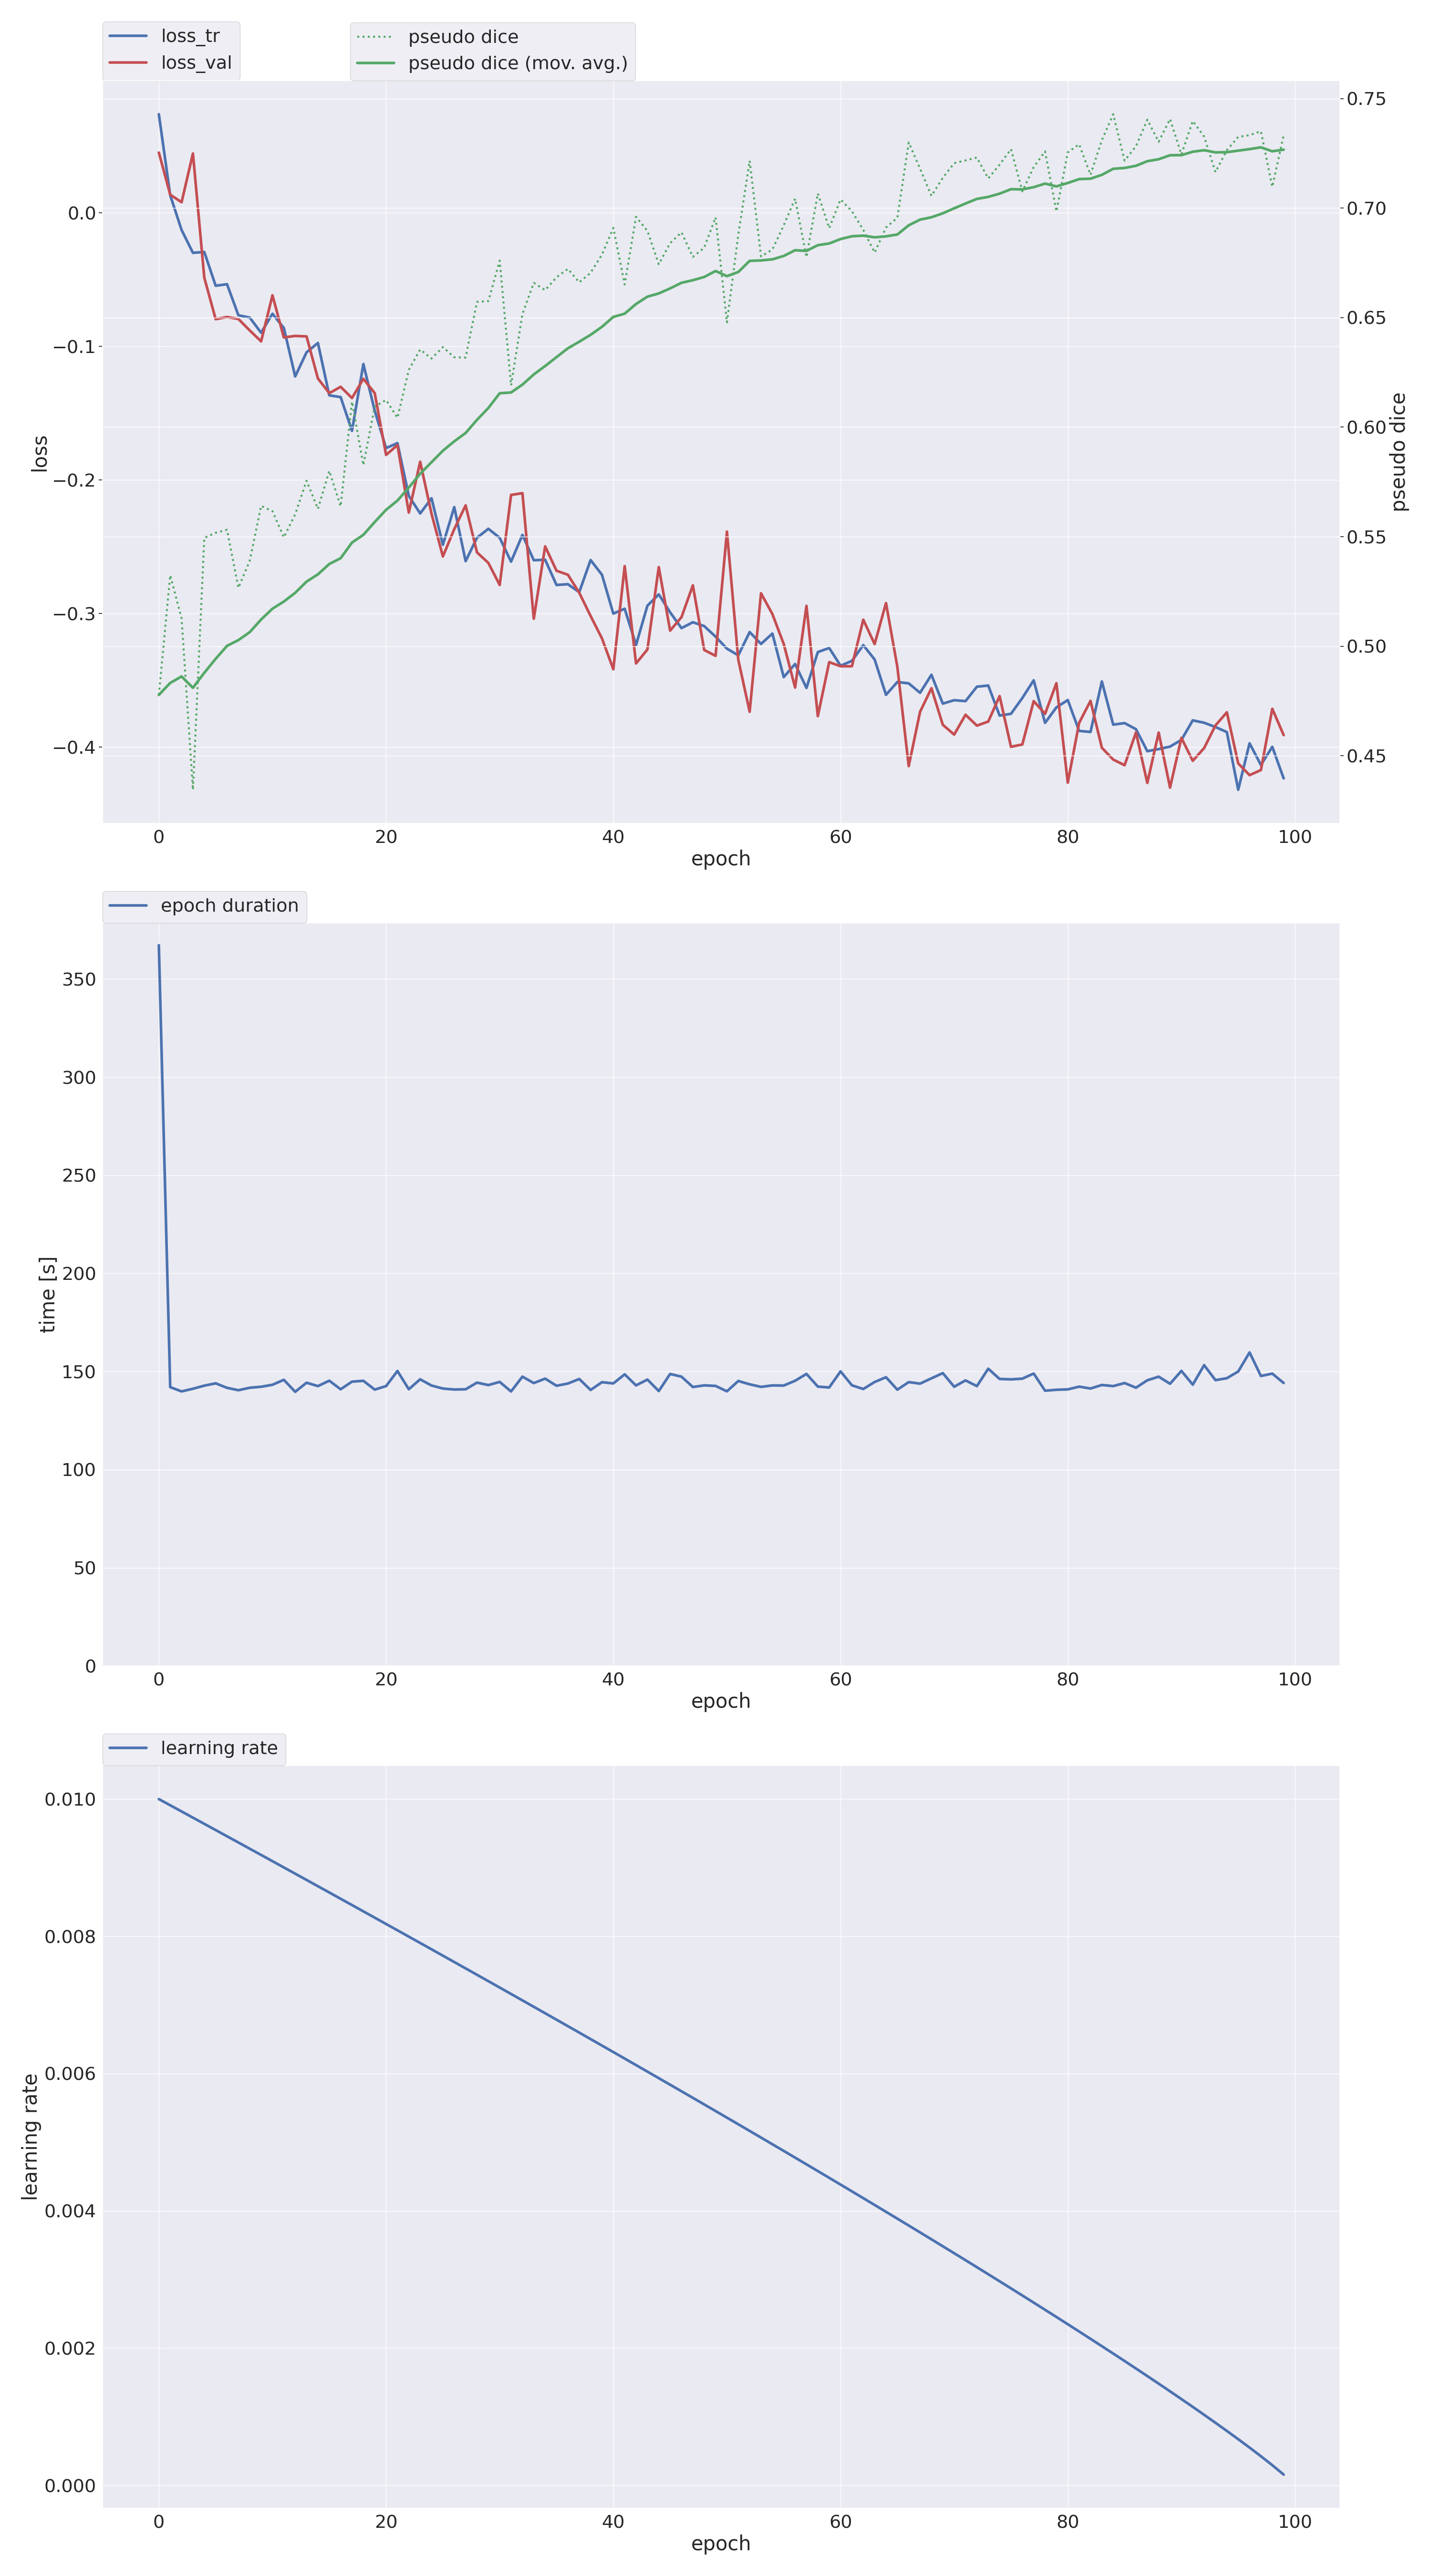


[Visualization] Sample prediction:
Found 1 predictions
Visualizing: 1407735.tif


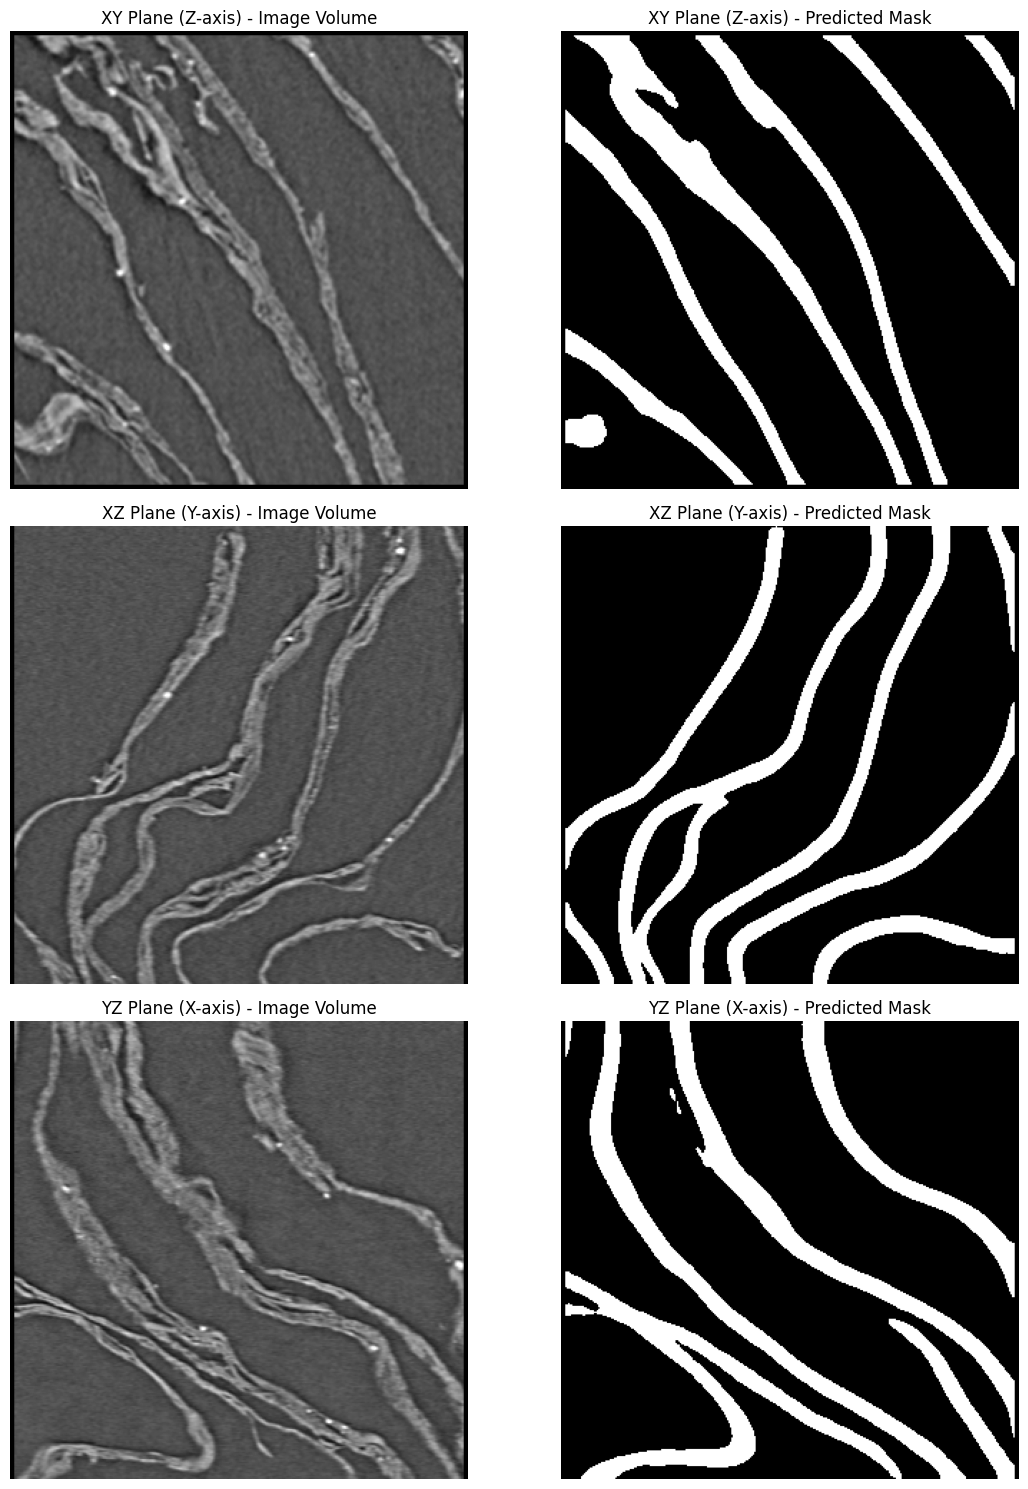

Creating submission ZIP with 1 files...


Zipping predictions:   0%|          | 0/1 [00:00<?, ?it/s]

Submission saved: /kaggle/working/submission.zip (0.7 MB)


PosixPath('/kaggle/working/submission.zip')

In [ ]:
# 示例：训练 100 epochs（可按需调整）
full_pipeline(
    epochs=8000,
    config="3d_fullres",
    fold=all)

# 训练完成后，如果只想用最佳模型做推理，可以这样：
# full_pipeline(
#     do_preprocess=False, do_train=False,
#     model_path="/kaggle/input/surface-nnunet-checkpoints/pytorch/default/.../checkpoint_best.pth",
# )

# 生成提交 ZIP
generate_submission()